# Part 4c — Cournot competition with endogenous price

### Where flooding the market becomes rational

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/USERNAME/lithium-modelling/blob/main/notebooks/04c_cournot.ipynb)

Part 4b had a **fixed** price, so rivalry was a pure race for a capped market and the only channel
between firms was residual demand. That produced two artefacts: a large first-mover advantage, and
an equilibrium that served less demand than a planner would.

Here price responds to quantity:

$$p_{rt,p} \;=\; A_{rt,p} - B_{rt,p} \sum_{r} \text{sale}_{r,rt,p}$$

That single change alters the economics qualitatively. Extra output now **depresses the rival's
margin as well as your own** — and because operating-cost learning is driven by cumulative
production, extra output also **advances your own learning tier**. Those two effects together are
the documented predatory dynamic: flood the market, starve the entrant, and come out cheaper.

### What is new

| | 4b (fixed price) | **4c (Cournot)** |
|---|---|---|
| Price | exogenous constant | $A - BQ$, endogenous |
| Firm objective | $\bar{p}\cdot\text{sales} - \text{cost}$ | quadratic revenue − cost |
| Rivalry channel | residual demand cap | **the price itself** |
| Quantity cap | rival's leftovers | choke price only |
| Benchmark | cooperative planner | **collusion** (joint profit max) |

### How to read this notebook

Sections 1–7 build the model **by hand**, one idea per cell, so you see every constraint before you
see any abstraction. Section 8 wraps what you built into three functions, because the analysis needs
them a dozen times — and checks the wrapper reproduces the hand-built answer before using it.
Section 12 imports the `lithium` package, runs the same case, and asserts the two agree to $10^{-9}$.
That last cell is what makes it safe for the same model to exist twice.

## 0. Setup

One cell, and it is the only place the `lithium` package appears before the final check. On Colab it
clones the repo and installs it; locally it assumes you have already run `pip install -e .` and just
moves up out of `notebooks/` so the relative data paths work.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/USERNAME/lithium-modelling.git"   # <-- edit me
REPO_NAME = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")

if "google.colab" in sys.modules:
    if not Path(REPO_NAME).exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_NAME)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "."], check=True)
elif Path.cwd().name == "notebooks":
    os.chdir("..")

import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"font.size": 12, "axes.grid": True, "grid.alpha": 0.3})
print(f"working directory : {Path.cwd().name}")
print(f"gurobipy          : {gp.gurobi.version()}")
print(f"pandas            : {pd.__version__}")

working directory : Advanced Opt Modeling Examples
gurobipy          : (13, 0, 2)
pandas            : 2.3.3


## 1. The formulation problem, and a neat way around it

Firm $r$'s revenue in market $rt$, taking the rival's quantity $\bar{q}$ as given:

$$\big(A - B(s + \bar{q})\big)\, s \;=\; \underbrace{(A - B\bar{q})}_{a_{\text{eff}}}\, s \;-\; B s^2$$

This is **quadratic**, so each best response is naturally a MIQP. Two reasons not to do that:
Gurobi's size-limited `pip` licence does not accept quadratic objectives at this model size, and a
MIQP is heavier than it needs to be.

**Piecewise-linearise the revenue instead.** And here the curvature works in our favour:

| | Minimising | Maximising |
|---|---|---|
| **Convex** | safe | chord exploited |
| **Concave** | **chord exploited** (Part 3's learning curve) | **safe** ← we are here |

Revenue is **concave** and we **maximise**, so every chord lies *below* the true curve. A free
convex combination of breakpoints has no incentive to mix non-adjacent points — mixing would report
*less* revenue. So this needs **no SOS2 and adds no binaries**, unlike Part 3's cumulative cost
curve. It is the exact mirror image, and worth pausing on: whether you need SOS2 depends on
curvature *and* optimisation direction together, never on one alone.

You will see both cases in this notebook — the capacity-learning curve in section 5 needs SOS2, and
the revenue curve in section 7 does not.

## 2. The instance tables

Two kinds of number go into this model and they are treated differently.

A **knob** is a scalar carrying a concept — the discount rate, the number of revenue breakpoints,
the choke price. Knobs stay written out in the cell where they are explained, because seeing
`NBP_REV = 7` next to the sentence describing what a breakpoint mesh does *is* the lesson. This
notebook hands every knob to the package explicitly in section 12, so the agreement assertion covers
them.

A **table** is instance data — many entries, indexed by the model's own sets, named nowhere in the
prose. Tables live in `data/raw/`, and both this notebook and `src/lithium/` read the same file. If
each typed its own copy, a failed assertion could not tell a typo in the data from a bug in a
constraint. Three tables, three key structures:

| file | keyed by | rows |
|---|---|---|
| `instance_base.csv` | `(stage, region)` | 6 |
| `efficiency.csv` | `stage` | 3 |
| `market.csv` | `region` | 2 |

Read the base table first and look at it as a **frame** — rows and columns — before turning it into
anything the model can index.

In [2]:
DATA = Path("data/raw")

if not (DATA / "instance_base.csv").exists():
    print("!" * 78)
    print("! data/raw/ was not found, so this notebook is FALLING BACK to generated")
    print("! numbers. Everything below will run and every figure will render, but the")
    print("! results are NOT the shipped instance and are NOT an acceptable submission.")
    print("! Fix: clone the repo (see section 0) or run this notebook from the repo root.")
    print("!" * 78)
    DATA = Path("_generated_fallback")
    DATA.mkdir(exist_ok=True)
    (DATA / "instance_base.csv").write_text(
        "stage,region,fixed,unit,opex,legacy_cap,legacy_ret\n"
        + "\n".join(f"{s},{r},1000.0,8.0,2.0,150,15"
                    for r in ("R1", "R2") for s in ("MINE", "PROC", "MFG")) + "\n")
    (DATA / "efficiency.csv").write_text(
        "stage,eta_ceil,eta_base,alpha,beta,delta_bar\n"
        "MINE,0.92,0.86,0.0,0.0,0.02\nPROC,0.95,0.80,0.03,0.01,0.05\n"
        "MFG,0.93,0.78,0.025,0.008,0.05\n")
    (DATA / "market.csv").write_text(
        "region,demand_base,demand_growth,experience0\n"
        "R1,100.0,0.008,1000.0\nR2,75.0,0.026,1000.0\n")

base = pd.read_csv(DATA / "instance_base.csv")
print(f"instance_base.csv: {len(base)} rows x {len(base.columns)} columns")
base

instance_base.csv: 6 rows x 7 columns


,stage,region,fixed,unit,opex,legacy_cap,legacy_ret
0,MINE,R1,900.0,7.0,1.20,230,11
1,PROC,R1,1500.0,11.0,2.00,205,14
2,MFG,R1,1300.0,9.5,2.40,155,18
3,MINE,R2,820.0,6.4,1.35,165,9
4,PROC,R2,1350.0,10.0,2.20,125,16
5,MFG,R2,1180.0,8.7,2.60,100,22


The other two tables. `efficiency.csv` is keyed by stage alone — a mine's yield behaviour does not
depend on which region owns it — and `market.csv` is keyed by region alone.

In [3]:
eff = pd.read_csv(DATA / "efficiency.csv")
mkt = pd.read_csv(DATA / "market.csv")
print(f"efficiency.csv: {len(eff)} rows    market.csv: {len(mkt)} rows")
display(eff)
mkt

efficiency.csv: 3 rows    market.csv: 2 rows


,stage,eta_ceil,eta_base,alpha,beta,delta_bar
0,MINE,0.92,0.86,0.000,0.000,0.02
1,PROC,0.95,0.80,0.030,0.010,0.05
2,MFG,0.93,0.78,0.025,0.008,0.05


,region,demand_base,demand_growth,experience0
0,R1,100.0,0.008,2600.0
1,R2,75.0,0.026,500.0


### 2.1 From table to lookup — see the key

A frame shows rows and columns. **The model does not index by row number.** Every constraint below
looks a value up by a *key*: `FIXED['PROC', 'R1']`, `ETA_CEIL['MFG']`, `EXPERIENCE0['R2']`. That key
is what connects the data to the algebra, so build the dictionaries and print them in the form the
constraints will actually use, rather than leaving the index set implied by punctuation.

The two index sets come out of the tables themselves, in file order — so the order the model
iterates in is a property of the data, not of a sorted() call somewhere.

In [4]:
STAGES = list(dict.fromkeys(eff["stage"]))
REGIONS = list(dict.fromkeys(mkt["region"]))

FIXED = {(r.stage, r.region): r.fixed for r in base.itertuples()}
UNIT = {(r.stage, r.region): r.unit for r in base.itertuples()}
OPEX = {(r.stage, r.region): r.opex for r in base.itertuples()}
LEGACY_CAP = {(r.stage, r.region): float(r.legacy_cap) for r in base.itertuples()}
LEGACY_RET = {(r.stage, r.region): int(r.legacy_ret) for r in base.itertuples()}

print(f"index sets:  STAGES  = {STAGES}")
print(f"             REGIONS = {REGIONS}")
print(f"{len(FIXED)} keys, each a (stage, region) tuple\n")
print(f"{'key':18s} {'FIXED':>8s} {'UNIT':>7s} {'OPEX':>6s} {'LEG_CAP':>8s} {'LEG_RET':>8s}")
for s in STAGES:
    for r in REGIONS:
        print(f"{str((s, r)):18s} {FIXED[s, r]:8.1f} {UNIT[s, r]:7.2f} {OPEX[s, r]:6.2f}"
              f" {LEGACY_CAP[s, r]:8.0f} {LEGACY_RET[s, r]:8d}")

index sets:  STAGES  = ['MINE', 'PROC', 'MFG']
             REGIONS = ['R1', 'R2']
6 keys, each a (stage, region) tuple

key                   FIXED    UNIT   OPEX  LEG_CAP  LEG_RET
('MINE', 'R1')        900.0    7.00   1.20      230       11
('MINE', 'R2')        820.0    6.40   1.35      165        9
('PROC', 'R1')       1500.0   11.00   2.00      205       14
('PROC', 'R2')       1350.0   10.00   2.20      125       16
('MFG', 'R1')        1300.0    9.50   2.40      155       18
('MFG', 'R2')        1180.0    8.70   2.60      100       22


The same move for the two single-key tables. Note `EXPERIENCE0`: R1 starts with 2,600 units of
accumulated production experience against R2's 500. Nothing in this instance is labelled
"incumbent" — that word is a *reading* of three numbers pulling the same way: R1 starts with more
experience, larger inherited plants, and the bigger home market. R2's compensating advantage is in
`instance_base.csv`, and it is capital, not operating cost: R2 is cheaper to **build** at every stage
and more expensive to **run** at every stage. Check that against the table above before going on,
because most of the results below turn on it.

In [5]:
ETA_CEIL = {r.stage: r.eta_ceil for r in eff.itertuples()}
ETA_BASE = {r.stage: r.eta_base for r in eff.itertuples()}
ALPHA = {r.stage: r.alpha for r in eff.itertuples()}
BETA = {r.stage: r.beta for r in eff.itertuples()}
DELTA_BAR = {r.stage: r.delta_bar for r in eff.itertuples()}

DEMAND_BASE = {r.region: r.demand_base for r in mkt.itertuples()}
DEMAND_GROWTH = {r.region: r.demand_growth for r in mkt.itertuples()}
EXPERIENCE0 = {r.region: r.experience0 for r in mkt.itertuples()}

print("keyed by stage :")
for s in STAGES:
    print(f"  {s!r:8s} ceil {ETA_CEIL[s]:.2f}  base {ETA_BASE[s]:.2f}  alpha {ALPHA[s]:.3f}"
          f"  beta {BETA[s]:.3f}  delta_bar {DELTA_BAR[s]:.2f}")
print("\nkeyed by region:")
for r in REGIONS:
    print(f"  {r!r:6s} demand_base {DEMAND_BASE[r]:6.1f}  growth {DEMAND_GROWTH[r]:.3f}"
          f"  experience0 {EXPERIENCE0[r]:7.1f}")

keyed by stage :
  'MINE'   ceil 0.92  base 0.86  alpha 0.000  beta 0.000  delta_bar 0.02
  'PROC'   ceil 0.95  base 0.80  alpha 0.030  beta 0.010  delta_bar 0.05
  'MFG'    ceil 0.93  base 0.78  alpha 0.025  beta 0.008  delta_bar 0.05

keyed by region:
  'R1'   demand_base  100.0  growth 0.008  experience0  2600.0
  'R2'   demand_base   75.0  growth 0.026  experience0   500.0


### 2.2 Want to experiment? Change a number here, not in the CSV

Each table is now a dictionary keyed the way the model indexes. Assign to a key to override one
entry. The change flows into every model built below **and** into the section 12 agreement check,
because the package takes the data as an argument instead of re-reading the file — so the assertion
stays green and you can see exactly what your edit did.

In [6]:
# ---------------------------------------------------------------------------
# Example - give R2 the same processing opex as R1 (2.0 instead of its 2.2):
#
#     OPEX['PROC', 'R2'] = 2.00
#
# Uncomment, then re-run this cell and everything below it. This erases R1's
# operating-cost edge at the processing stage, so R2 gets cheaper to run, its
# equilibrium share rises, and the section 12 assertion stays green because the
# notebook passes OPEX to the package rather than letting it re-read the file.
# Re-run with it commented out to get the shipped instance back.
# ---------------------------------------------------------------------------
print(f"OPEX['PROC', 'R2'] is currently {OPEX['PROC', 'R2']}")

OPEX['PROC', 'R2'] is currently 2.2


## 3. The knobs, and the structure derived from them

Everything from here to section 5 is **derived**: sets, windows, discount weights, yields. None of
it is data and none of it is a knob — it is arithmetic on the two, and doing that arithmetic is the
point of this section. `src/lithium/structure.py` computes exactly the same things, and section 12
is what proves the two derivations agree.

### 3.1 Time: variable-length periods

A 37-year horizon at annual resolution would be 37 copies of every decision. Instead the horizon is
chopped into **13 periods of increasing length** — six 1-year periods while the interesting things
happen, then 3-, 5- and finally 9-year blocks. `OMEGA[p]` is the sum of discount factors for the
years inside period `p`, so a long late period is correctly worth less per year *and* covers more
years.

In [7]:
BLOCKS = [(6, 1), (4, 3), (2, 5), (1, 9)]   # (how many periods, how many years each)
DR = 0.05                                    # discount rate

LEN, START = [], []
_y = 1
for _count, _length in BLOCKS:
    for _ in range(_count):
        LEN.append(_length)
        START.append(_y)
        _y += _length

P = list(range(len(LEN)))
HORIZON = _y - 1
YEARS = {p: list(range(START[p], START[p] + LEN[p])) for p in P}
OMEGA = {p: sum(1 / (1 + DR) ** t for t in YEARS[p]) for p in P}
YEAR_TO_P = {t: p for p in P for t in YEARS[p]}

print(f"{len(P)} periods covering {HORIZON} years")
print(f"{'p':>3s} {'start':>6s} {'len':>4s} {'OMEGA':>8s}")
for p in P:
    print(f"{p:3d} {START[p]:6d} {LEN[p]:4d} {OMEGA[p]:8.4f}")

13 periods covering 37 years
  p  start  len    OMEGA
  0      1    1   0.9524
  1      2    1   0.9070
  2      3    1   0.8638
  3      4    1   0.8227
  4      5    1   0.7835
  5      6    1   0.7462
  6      7    3   2.0321
  7     10    3   1.7554
  8     13    3   1.5164
  9     16    3   1.3099
 10     19    5   1.7990
 11     24    5   1.4096
 12     29    9   1.8132


### 3.2 Technology: turning a lump of capex into an annual charge

A plant built in period `v` is paid for once and used for `LIFE` years. `CRF` is the capital
recovery factor that spreads that lump into equal annual payments, and `MU[s, v]` discounts those
payments back to today — truncated at the horizon, so a plant built late gets credit only for the
years that actually fall inside the model.

`LEAD` is the construction lag: decide in period `v`, produce from `START[v] + LEAD[s]`.

In [8]:
LIFE = 25
LEAD = {'MINE': 1, 'PROC': 2, 'MFG': 2}
CAP_MIN, CAP_MAX = 60.0, 260.0

CRF = DR * (1 + DR) ** LIFE / ((1 + DR) ** LIFE - 1)
ONLINE = {(s, p): START[p] + LEAD[s] for s in STAGES for p in P}
MU = {(s, v): CRF * sum(1 / (1 + DR) ** t
                        for t in range(ONLINE[s, v], ONLINE[s, v] + LIFE)
                        if t <= HORIZON)
      for s in STAGES for v in P}

print(f"CRF = {CRF:.6f}   (a 1.0 lump becomes {CRF:.4f} per year for {LIFE} years)")
print(f"\nMU['PROC', v] by build period - note the collapse as v approaches the horizon:")
print("  " + "  ".join(f"v{v}:{MU['PROC', v]:5.2f}" for v in P))

CRF = 0.070952   (a 1.0 lump becomes 0.0710 per year for 25 years)

MU['PROC', v] by build period - note the collapse as v approaches the horizon:
  v0: 0.91  v1: 0.86  v2: 0.82  v3: 0.78  v4: 0.75  v5: 0.71  v6: 0.68  v7: 0.58  v8: 0.48  v9: 0.39  v10: 0.30  v11: 0.19  v12: 0.09


### 3.3 Efficiency: yield depends on when a plant was built and how old it is

Two effects, and they pull in opposite directions. A plant built later starts closer to the
technological ceiling (`ALPHA` — the frontier improves). A plant that has been running for a while
also drifts up towards the ceiling through operating experience (`BETA`), but only by at most
`DELTA_BAR` above where it started. `ETA_FLOOR` stops the arithmetic producing a nonsense yield.

`LEGACY_BYR = -8` says the inherited plants were built eight years before year 1 — which is why they
sit well below the frontier.

In [9]:
ETA_FLOOR = 0.60
LEGACY_BYR = -8

VINTAGES = [-1] + P                      # -1 is the inherited fleet
BYEAR = {v: (LEGACY_BYR if v == -1 else START[v]) for v in VINTAGES}

ETA = {}
for s in STAGES:
    for v in VINTAGES:
        fr = ETA_CEIL[s] - (ETA_CEIL[s] - ETA_BASE[s]) * (1 - ALPHA[s]) ** (BYEAR[v] - 1)
        fr = max(ETA_FLOOR, min(fr, ETA_CEIL[s]))
        for p in P:
            age = max(0, START[p] - BYEAR[v])
            aged = ETA_CEIL[s] - (ETA_CEIL[s] - fr) * (1 - BETA[s]) ** age
            ETA[s, v, p] = max(ETA_FLOOR, min(fr + DELTA_BAR[s], aged))

print(f"{len(ETA)} yields, keyed (stage, vintage, period)\n")
print("PROC yield in period 0, by vintage - the frontier effect:")
print("  legacy (v=-1): %.4f" % ETA['PROC', -1, 0])
print("  " + "  ".join(f"v{v}:{ETA['PROC', v, 0]:.4f}" for v in P[:5]))
print("\nlegacy PROC plant ageing through the horizon:")
print("  " + "  ".join(f"p{p}:{ETA['PROC', -1, p]:.4f}" for p in P[:6]))

546 yields, keyed (stage, vintage, period)

PROC yield in period 0, by vintage - the frontier effect:
  legacy (v=-1): 0.7698
  v0:0.8000  v1:0.8045  v2:0.8089  v3:0.8131  v4:0.8172

legacy PROC plant ageing through the horizon:
  p0:0.7698  p1:0.7716  p2:0.7733  p3:0.7751  p4:0.7769  p5:0.7786


### 3.4 Demand

Each region's demand grows from its own base at its own rate. R2 is the smaller market but grows
more than three times as fast, which is why the entrant's home turf is worth fighting for later even
though it is worth less now. The value stored is the **average annual** demand across the period, so
it is comparable across periods of different length.

In [10]:
DEMAND = {(r, p): sum(DEMAND_BASE[r] * (1 + DEMAND_GROWTH[r]) ** (t - 1) for t in YEARS[p]) / LEN[p]
          for r in REGIONS for p in P}

print(f"average annual demand ({len(DEMAND)} keys, (region, period)):")
print(f"{'p':>3s} {'year':>5s} " + " ".join(f"{r:>8s}" for r in REGIONS))
for p in P:
    print(f"{p:3d} {START[p]:5d} " + " ".join(f"{DEMAND[r, p]:8.2f}" for r in REGIONS))

average annual demand (26 keys, (region, period)):
  p  year       R1       R2
  0     1   100.00    75.00
  1     2   100.80    76.95
  2     3   101.61    78.95
  3     4   102.42    81.00
  4     5   103.24    83.11
  5     6   104.06    85.27
  6     7   105.74    89.78
  7    10   108.30    96.97
  8    13   110.92   104.73
  9    16   113.60   113.11
 10    19   117.28   125.40
 11    24   122.05   142.57
 12    29   129.07   170.90


### 3.5 Who can produce, when

Three sets that every constraint below indexes over, and they are worth printing rather than
trusting:

- `ACTIVE[r]` — the `(stage, vintage, period)` triples that exist at all: an inherited plant until
  its retirement year, a new plant from the period it comes online until it has run for `LIFE` years.
- `VIN[r, s, p]` — the vintages available at one stage in one period. This is the set the chain
  balance sums over.
- `BUILD[r]` — the `(stage, vintage)` pairs that could be built, i.e. those that come online before
  the horizon ends.

In [11]:
ACTIVE = {r: [(s, v, p) for s in STAGES for v in VINTAGES for p in P
              if (v == -1 and START[p] <= LEGACY_RET[s, r])
              or (v >= 0 and ONLINE[s, v] <= START[p] <= ONLINE[s, v] + LIFE - 1)]
          for r in REGIONS}
VIN = {(r, s, p): [v for (ss, v, pp) in ACTIVE[r] if (ss, pp) == (s, p)]
       for r in REGIONS for s in STAGES for p in P}
BUILD = {r: [(s, v) for s in STAGES for v in P if ONLINE[s, v] <= HORIZON]
         for r in REGIONS}

for r in REGIONS:
    print(f"{r}: {len(ACTIVE[r]):4d} active (stage, vintage, period) triples, "
          f"{len(BUILD[r]):3d} buildable (stage, vintage) pairs")
print(f"\nVIN['R1', 'MFG', p] - vintages that can manufacture, period by period:")
for p in P:
    print(f"  p{p:<2d} {VIN['R1', 'MFG', p]}")

R1:  242 active (stage, vintage, period) triples,  39 buildable (stage, vintage) pairs
R2:  243 active (stage, vintage, period) triples,  39 buildable (stage, vintage) pairs

VIN['R1', 'MFG', p] - vintages that can manufacture, period by period:
  p0  [-1]
  p1  [-1]
  p2  [-1, 0]
  p3  [-1, 0, 1]
  p4  [-1, 0, 1, 2]
  p5  [-1, 0, 1, 2, 3]
  p6  [-1, 0, 1, 2, 3, 4]
  p7  [-1, 0, 1, 2, 3, 4, 5, 6]
  p8  [-1, 0, 1, 2, 3, 4, 5, 6, 7]
  p9  [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
  p10 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  p11 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  p12 [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


### 3.6 The remaining knobs: moving goods and the two penalties

`TRANSPORT` is nearly five times more expensive across regions than within one. That single number
is what makes geography matter — without it the two markets would collapse into one.

In [12]:
TRANSPORT_OWN, TRANSPORT_CROSS = 0.5, 2.4
TRANSPORT = {(rf, rt): (TRANSPORT_OWN if rf == rt else TRANSPORT_CROSS)
             for rf in REGIONS for rt in REGIONS}

PRICE_FIXED = 12.0     # the Part 4b price; kept so 4b's revenue term stays available
PEN_SHORT = 90.0       # planner-only: cost of leaving demand unserved
PEN_DISPOSE = 12.0     # cost of destroying output rather than selling it

print("TRANSPORT, keyed (from, to):")
for k, v in TRANSPORT.items():
    print(f"  {str(k):14s} {v:4.1f}")
print(f"\nPEN_DISPOSE = {PEN_DISPOSE}  <- watch this one: section 10 shows it never binds")

TRANSPORT, keyed (from, to):
  ('R1', 'R1')    0.5
  ('R1', 'R2')    2.4
  ('R2', 'R1')    2.4
  ('R2', 'R2')    0.5

PEN_DISPOSE = 12.0  <- watch this one: section 10 shows it never binds


## 4. The capacity-learning curve

Building capacity gets cheaper the more of it you have built. A learning rate `LR_CAPEX = 0.15`
means unit cost falls 15% per doubling of cumulative capacity, which is the exponent
$-\log_2(1 - 0.15)$.

**The model needs the area under that curve, not the curve itself.** Total spend to go from
`Q_START` to `Q` is the integral of the unit cost over that range — building the 401st unit costs
what the curve says at 401, not what it said at 300. So we integrate numerically (trapezoid rule,
`PANELS` panels) at each of `NBP` breakpoints, and the model interpolates between them.

**This curve is concave and it enters a cost we are *minimising*** — so a chord between two
breakpoints lies *below* the true cumulative cost, and a free convex combination would happily mix
distant breakpoints to claim a discount that does not exist. That is why the model in section 5 adds
**SOS2** here. Compare section 7, where the same concave shape in a *maximisation* needs nothing.

In [13]:
import math

LEARN_STAGES = ['PROC', 'MFG']
LR_CAPEX = 0.15        # cost falls 15% per doubling
Q_START = 300.0        # cumulative capacity at which learning starts
Q_ADD = 700.0          # how much further the mesh reaches
CAPEX_FLOOR = 0.60     # the multiplier cannot fall below this
NBP = 9                # breakpoints on the capex mesh
PANELS = 400           # trapezoid panels per breakpoint

_bc = -math.log2(1 - LR_CAPEX)
K = list(range(NBP))                     # the breakpoint index the model sums over
QBP = [Q_START + Q_ADD * k / (NBP - 1) for k in K]

CBP = []
for q in QBP:
    if q <= Q_START:
        CBP.append(0.0)
        continue
    h = (q - Q_START) / PANELS
    grid = [Q_START + i * h for i in range(PANELS + 1)]
    unit = [max(CAPEX_FLOOR, (g / Q_START) ** (-_bc)) for g in grid]
    CBP.append(sum(0.5 * (unit[i] + unit[i + 1]) * h for i in range(PANELS)))

print(f"learning exponent b = {_bc:.4f}\n")
print(f"{'k':>2s} {'QBP (cum capacity)':>19s} {'unit mult':>10s} {'CBP (cum spend mult)':>21s}")
for k in range(NBP):
    print(f"{k:2d} {QBP[k]:19.1f} {max(CAPEX_FLOOR, (QBP[k] / Q_START) ** (-_bc)):10.4f}"
          f" {CBP[k]:21.2f}")

learning exponent b = 0.2345

 k  QBP (cum capacity)  unit mult  CBP (cum spend mult)
 0               300.0     1.0000                  0.00
 1               387.5     0.9418                 84.82
 2               475.0     0.8979                165.22
 3               562.5     0.8630                242.20
 4               650.0     0.8342                316.42
 5               737.5     0.8099                388.32
 6               825.0     0.7888                458.24
 7               912.5     0.7704                526.44
 8              1000.0     0.7541                593.12


## 5. The chain, built by hand

A **region** here is a whole vertically-integrated business: it mines ore, processes it, manufactures
the finished good, and sells into either market. The next seven cells build that chain for both
regions, one block of constraints at a time.

We build it first as a **cooperative planner** — one decision maker minimising the weighted sum of
both regions' costs subject to meeting demand. That is Part 4a's model, and we need it here for a
specific reason given in section 6: it tells us the *scale* at which this chain operates, and the
operating-cost learning tiers have to be calibrated against a scale.

### 5.1 The decision variables

Seven families per region. `b` is the only binary block — build or don't — and everything else is
continuous, which is a deliberate choice from Part 3 that pays off in Part 4d.

In [14]:
m = gp.Model("planner")
m.Params.OutputFlag = 0
m.Params.MIPGap = 0.005

b, c, x, f_mp, f_pf, sale, disp = {}, {}, {}, {}, {}, {}, {}
for r in REGIONS:
    b[r] = m.addVars(BUILD[r], vtype=GRB.BINARY, name=f'b_{r}')      # build it?
    c[r] = m.addVars(BUILD[r], lb=0.0, ub=CAP_MAX, name=f'c_{r}')    # how big?
    x[r] = m.addVars(ACTIVE[r], lb=0.0, name=f'x_{r}')               # throughput
    f_mp[r] = m.addVars(P, lb=0.0, name=f'fmp_{r}')                  # mine -> proc flow
    f_pf[r] = m.addVars(P, lb=0.0, name=f'fpf_{r}')                  # proc -> mfg flow
    sale[r] = m.addVars(REGIONS, P, lb=0.0, name=f'sale_{r}')        # sales into each market
    disp[r] = m.addVars(P, lb=0.0, name=f'disp_{r}')                 # destroyed output

m.update()
print(f"{m.NumVars} variables, of which {m.NumBinVars} binary")
print(f"per region: {len(BUILD['R1'])} build pairs, {len(ACTIVE['R1'])} throughput triples")

Set parameter Username


Set parameter LicenseID to value 2750151


Academic license - for non-commercial use only - expires 2026-12-04


771 variables, of which 78 binary
per region: 39 build pairs, 242 throughput triples


### 5.2 Capacity: a plant you did not build cannot run

Three constraints, and the first two are the classic big-M pair that ties a continuous size to a
binary decision. `c <= CAP_MAX * b` forces size to zero when you don't build; `c >= CAP_MIN * b`
forces a *minimum viable scale* when you do — you cannot build a token 3-unit plant. Together they
make capacity a semi-continuous variable.

The third says throughput never exceeds the capacity available: inherited plants are capped by their
legacy size, new ones by whatever `c` was chosen.

In [15]:
for r in REGIONS:
    m.addConstrs((c[r][s, v] <= CAP_MAX * b[r][s, v] for (s, v) in BUILD[r]), name=f'su_{r}')
    m.addConstrs((c[r][s, v] >= CAP_MIN * b[r][s, v] for (s, v) in BUILD[r]), name=f'sl_{r}')
    m.addConstrs((x[r][s, v, p] <= (LEGACY_CAP[s, r] if v == -1 else c[r][s, v])
                  for (s, v, p) in ACTIVE[r]), name=f'cap_{r}')

m.update()
print(f"{m.NumConstrs} constraints after the capacity block")

641 constraints after the capacity block


### 5.3 The chain balance: what comes out of one stage goes into the next

Five constraints per region per period, and they are the physical heart of the model. Ore mined,
multiplied by the mine's **yield**, has to equal the flow into processing; that flow has to equal
what processing takes in; and so on down to manufactured output, which must equal what is sold plus
what is thrown away.

The yield `ETA[s, v, p]` is where section 3.3's work shows up: an old inherited plant loses more of
the material at every step, so it needs more ore to deliver the same finished tonne.

In [16]:
for r in REGIONS:
    m.addConstrs((gp.quicksum(ETA['MINE', v, p] * x[r]['MINE', v, p]
                              for v in VIN[r, 'MINE', p]) == f_mp[r][p] for p in P),
                 name=f'mine_{r}')
    m.addConstrs((f_mp[r][p] == gp.quicksum(x[r]['PROC', v, p] for v in VIN[r, 'PROC', p])
                  for p in P), name=f'pin_{r}')
    m.addConstrs((gp.quicksum(ETA['PROC', v, p] * x[r]['PROC', v, p]
                              for v in VIN[r, 'PROC', p]) == f_pf[r][p] for p in P),
                 name=f'pout_{r}')
    m.addConstrs((f_pf[r][p] == gp.quicksum(x[r]['MFG', v, p] for v in VIN[r, 'MFG', p])
                  for p in P), name=f'min_{r}')
    m.addConstrs((gp.quicksum(ETA['MFG', v, p] * x[r]['MFG', v, p]
                              for v in VIN[r, 'MFG', p])
                  == sale[r].sum('*', p) + disp[r][p] for p in P), name=f'mout_{r}')

m.update()
print(f"{m.NumConstrs} constraints after the chain balance")

771 constraints after the chain balance


### 5.4 Cumulative production, and the head start

`cum[p]` is everything the region has ever manufactured up to and including period `p`, undiscounted
— learning does not care about the time value of money — **plus `EXPERIENCE0[r]`**, the experience it
walked in with. Note `LEN[q] * x[...]`: a period of length 5 produces five years' worth.

This single variable is the one that turns quantity into a strategic weapon later. Selling more today
moves you up this curve, and section 10 is where that stops being a footnote.

In [17]:
cum = {}
for r in REGIONS:
    cum[r] = m.addVars(P, lb=0.0, ub=3 * CAP_MAX * HORIZON + EXPERIENCE0[r], name=f'cum_{r}')
    m.addConstrs((cum[r][p] == EXPERIENCE0[r] +
                  gp.quicksum(LEN[q] * x[r]['MFG', v, q] for q in P if q <= p
                              for v in VIN[r, 'MFG', q]) for p in P), name=f'cp_{r}')

m.update()
print("starting experience:", {r: EXPERIENCE0[r] for r in REGIONS})
print(f"upper bound on cum: ", {r: round(3 * CAP_MAX * HORIZON + EXPERIENCE0[r], 0) for r in REGIONS})

starting experience: {'R1': 2600.0, 'R2': 500.0}
upper bound on cum:  {'R1': 31460.0, 'R2': 29360.0}


### 5.5 Capital cost, and the SOS2 that section 4 warned about

Capex splits in two. Stages that do **not** learn are charged the ordinary way: an annuitised fixed
cost for deciding to build, plus an annuitised per-unit cost for the size.

Stages that **do** learn get the piecewise curve. `Q[p]` is cumulative learning-stage capacity by
period `p`, `Cc[p]` the cumulative spend multiplier read off the curve at that point, and `lam` the
convex-combination weights. The capex charged in period `p` is the *increment* `Cc[p] - Cc[p-1]` —
what this period's building added, not the whole area again.

**`m.addSOS(GRB.SOS_TYPE2, ...)` is the line that matters.** Without it the weights are free to
combine breakpoint 0 with breakpoint 8 and report a cost below the true curve, because the curve is
concave and this term is being minimised. SOS2 restricts the weights to at most two *adjacent*
breakpoints, which is exactly the interpolation we meant.

In [18]:
capex = {}
for r in REGIONS:
    capex[r] = (gp.quicksum(MU[s, v] * FIXED[s, r] * b[r][s, v] for (s, v) in BUILD[r])
                + gp.quicksum(MU[s, v] * UNIT[s, r] * c[r][s, v]
                              for (s, v) in BUILD[r] if s not in LEARN_STAGES))

    Q = m.addVars(P, lb=Q_START, ub=Q_START + Q_ADD, name=f'Q_{r}')
    Cc = m.addVars(P, lb=0.0, name=f'C_{r}')
    lam = m.addVars(P, K, lb=0.0, ub=1.0, name=f'lam_{r}')
    m.addConstrs((lam.sum(p, '*') == 1 for p in P), name=f'sc_{r}')
    m.addConstrs((Q[p] == gp.quicksum(QBP[k] * lam[p, k] for k in K) for p in P), name=f'sQ_{r}')
    m.addConstrs((Cc[p] == gp.quicksum(CBP[k] * lam[p, k] for k in K) for p in P), name=f'sC_{r}')
    m.addConstrs((Q[p] == Q_START + gp.quicksum(c[r][s, v] for (s, v) in BUILD[r]
                                                if s in LEARN_STAGES and v <= p)
                  for p in P), name=f'cc_{r}')
    for p in P:
        m.addSOS(GRB.SOS_TYPE2, [lam[p, k] for k in K])          # <-- the important line

    rate = sum(UNIT[s, r] for s in LEARN_STAGES) / len(LEARN_STAGES)
    capex[r] += gp.quicksum(MU['PROC', p] * rate * (Cc[p] - (Cc[p - 1] if p > 0 else 0.0))
                            for p in P)

m.update()
print(f"{m.NumVars} variables, {m.NumConstrs} constraints, {m.NumSOS} SOS2 sets")
print(f"({len(P)} periods x {len(REGIONS)} regions = {len(P) * len(REGIONS)} SOS2 sets, as expected)")

1083 variables, 901 constraints, 26 SOS2 sets
(13 periods x 2 regions = 26 SOS2 sets, as expected)


### 5.6 Operating cost, transport and disposal

Here the operating cost is **flat** — `OPEX[s, r]` per unit, no tiers. That is deliberate and
temporary: the tiered version needs a calibration this model has not produced yet. Section 6 does the
calibration and section 7 builds the tiered version.

`OMEGA[p]` appears on every operating term because these are annual flows inside a multi-year period,
where the capex terms above used `MU` because they are annuities on a lump.

In [19]:
cost = {}
for r in REGIONS:
    opex = gp.quicksum(OMEGA[p] * OPEX[s, r] * x[r][s, v, p] for (s, v, p) in ACTIVE[r])
    trans = gp.quicksum(OMEGA[p] * TRANSPORT[r, rt] * sale[r][rt, p]
                        for rt in REGIONS for p in P)
    dcost = gp.quicksum(OMEGA[p] * PEN_DISPOSE * disp[r][p] for p in P)
    cost[r] = capex[r] + opex + trans + dcost

print("cost expression built for", list(cost))
print(f"each has {cost['R1'].size()} linear terms")

cost expression built for ['R1', 'R2']
each has 358 linear terms


### 5.7 Meet demand, then solve

The planner has to serve both markets or pay `PEN_SHORT` per unit short. `w1 = 0.5` weights the two
regions equally.

> **Predict before you run.** R1 has the bigger market and far more accumulated experience; R2 is
> cheaper to build and cheaper to run at every stage. Write down which region you expect the planner
> to lean on for the *marginal* tonne, and whether you expect any demand to go unserved at a penalty
> of 90 against a transport cost of 2.4.

The `assert` before `optimize()` is a shape check, not a status check: an empty model also "succeeds".

In [20]:
W1 = 0.5
short = m.addVars(REGIONS, P, lb=0.0, name='short')
m.addConstrs((gp.quicksum(sale[r][rt, p] for r in REGIONS) + short[rt, p] >= DEMAND[rt, p]
              for rt in REGIONS for p in P), name='demand')
pen = gp.quicksum(OMEGA[p] * PEN_SHORT * short[rt, p] for rt in REGIONS for p in P)
m.setObjective(W1 * cost['R1'] + (1 - W1) * cost['R2'] + pen, GRB.MINIMIZE)

m.update()
assert m.NumVars > 0 and m.NumConstrs > 0, "empty model"
assert m.NumSOS == len(P) * len(REGIONS), "SOS2 sets went missing"

m.optimize()
assert m.SolCount > 0, f"no solution; status {m.Status}"
print(f"status {m.Status}, objective {m.ObjVal:,.1f}, MIP gap {m.MIPGap:.2e}")
print(f"unserved demand total: {sum(short[rt, p].X for rt in REGIONS for p in P):.3f}")
print("builds:", {r: sum(1 for k in BUILD[r] if b[r][k].X > 0.5) for r in REGIONS})

status 2, objective 22,023.6, MIP gap 4.71e-03
unserved demand total: 0.000
builds: {'R1': 3, 'R2': 3}


## 6. Calibrating the operating-cost tiers

Operating cost falls with cumulative production too, but through a different mechanism: a **step
function**, not a smooth curve. Below a threshold you pay full price; past it you drop to a cheaper
tier. `LR_OPEX = 0.18` sets the size of each step (18% cheaper per tier), `N_TIERS = 3` how many
there are.

The thresholds cannot be knobs, because a threshold is only meaningful relative to how much this
chain actually produces. So they are calibrated: take the cumulative production the planner just
reached, and place the first threshold at one eighth of it, the second at a quarter. Any region that
runs its chain hard passes both; one that idles passes neither.

**`LAG_YEARS = 3`** is the other idea here. Learning takes time to show up in the cost base, so the
tier applying in period `p` is decided by cumulative production three years *earlier*. That lag is
what stops a firm buying itself an instant discount in the period it produces.

In [21]:
LR_OPEX = 0.18        # each tier is 18% cheaper than the one before
OPEX_FLOOR = 0.65     # the multiplier cannot fall below this
N_TIERS = 3
LAG_YEARS = 3

top = {r: cum[r][P[-1]].X for r in REGIONS}

TIER_Q, TIER_M = {}, {}
for r in REGIONS:
    _t = max(top[r], 1.0)
    _q1 = _t / 8.0
    TIER_Q[r] = [_q1 * 2 ** j for j in range(N_TIERS - 1)]
    TIER_M[r] = [max(OPEX_FLOOR, (1 - LR_OPEX) ** j) for j in range(N_TIERS)]

print("cumulative production the planner reached, by the last period:")
for r in REGIONS:
    print(f"  {r}: {top[r]:10.2f}")
print(f"\n{N_TIERS} tiers means {N_TIERS - 1} thresholds (they are the boundaries between tiers):")
for r in REGIONS:
    print(f"  {r}: thresholds {[round(q, 1) for q in TIER_Q[r]]}"
          f"   multipliers {[round(v, 3) for v in TIER_M[r]]}")

cumulative production the planner reached, by the last period:
  R1:    8657.40
  R2:    5435.16

3 tiers means 2 thresholds (they are the boundaries between tiers):
  R1: thresholds [1082.2, 2164.3]   multipliers [1.0, 0.82, 0.672]
  R2: thresholds [679.4, 1358.8]   multipliers [1.0, 0.82, 0.672]


## 7. The Cournot best response, built by hand

Now the model this notebook is actually about. One firm, R1, choosing its whole investment and sales
plan to maximise **its own profit**, taking the rival's sales schedule as fixed.

Two things are new relative to section 5, and everything else is the same chain you already built:

1. **Tiered operating cost** — the block calibrated in section 6, which needs binaries.
2. **Endogenous price** — revenue is no longer `PRICE_FIXED * sales` but a piecewise-linearised
   quadratic.

### 7.1 Inverse demand

`CHOKE` is the price at zero quantity. `B` is calibrated so that when quantity equals the Part 4b
demand reference, price equals `P_ANCHOR` — the level at which the fixed-price game was interesting.
That makes 4b and 4c comparable at a reference point rather than at an arbitrary one.

In [22]:
CHOKE = 30.0       # price at zero quantity
P_ANCHOR = 13.0    # price when quantity equals the Part 4b demand reference

A_INT = {(rt, p): CHOKE for rt in REGIONS for p in P}
B_SLP = {(rt, p): (CHOKE - P_ANCHOR) / DEMAND[rt, p] for rt in REGIONS for p in P}

print(f"{'market':>7s} {'p':>3s} {'A (choke)':>10s} {'B (slope)':>10s} {'p at D':>8s}"
      f" {'max qty':>9s}")
for rt in REGIONS:
    for p in [0, 6, len(P) - 1]:
        q = DEMAND[rt, p]
        print(f"{rt:>7s} {p:3d} {A_INT[rt, p]:10.1f} {B_SLP[rt, p]:10.5f}"
              f" {A_INT[rt, p] - B_SLP[rt, p] * q:8.2f} {A_INT[rt, p] / B_SLP[rt, p]:9.1f}")

 market   p  A (choke)  B (slope)   p at D   max qty
     R1   0       30.0    0.17000    13.00     176.5
     R1   6       30.0    0.16077    13.00     186.6
     R1  12       30.0    0.13171    13.00     227.8
     R2   0       30.0    0.22667    13.00     132.4
     R2   6       30.0    0.18935    13.00     158.4
     R2  12       30.0    0.09948    13.00     301.6


### 7.2 The rival's schedule, and a fresh model

The best response is defined *against something*. We start where the iteration in section 9 starts:
a rival selling nothing. That makes this first solve a monopoly problem, and its answer is the
natural upper bound on what R1 can earn.

The next four cells rebuild the chain from section 5 — same variables, same constraints, now for R1
alone. Read them as a recap; the genuinely new blocks start at 7.4.

In [23]:
FIRM = 'R1'
rival_sales = {(rt, p): 0.0 for rt in REGIONS for p in P}

mb = gp.Model("best_response")
mb.Params.OutputFlag = 0
mb.Params.MIPGap = 1e-3

bb = mb.addVars(BUILD[FIRM], vtype=GRB.BINARY, name=f'b_{FIRM}')
cc_ = mb.addVars(BUILD[FIRM], lb=0.0, ub=CAP_MAX, name=f'c_{FIRM}')
xx = mb.addVars(ACTIVE[FIRM], lb=0.0, name=f'x_{FIRM}')
ff_mp = mb.addVars(P, lb=0.0, name=f'fmp_{FIRM}')
ff_pf = mb.addVars(P, lb=0.0, name=f'fpf_{FIRM}')
ss = mb.addVars(REGIONS, P, lb=0.0, name=f'sale_{FIRM}')
dd = mb.addVars(P, lb=0.0, name=f'disp_{FIRM}')

mb.update()
print(f"{mb.NumVars} variables for one firm ({mb.NumBinVars} binary)")
print(f"rival sells {sum(rival_sales.values()):.1f} in every market and period")

385 variables for one firm (39 binary)
rival sells 0.0 in every market and period


### 7.3 The same capacity, chain-balance, cumulative-production and capex blocks

In [24]:
mb.addConstrs((cc_[s, v] <= CAP_MAX * bb[s, v] for (s, v) in BUILD[FIRM]), name='su')
mb.addConstrs((cc_[s, v] >= CAP_MIN * bb[s, v] for (s, v) in BUILD[FIRM]), name='sl')
mb.addConstrs((xx[s, v, p] <= (LEGACY_CAP[s, FIRM] if v == -1 else cc_[s, v])
               for (s, v, p) in ACTIVE[FIRM]), name='cap')

mb.addConstrs((gp.quicksum(ETA['MINE', v, p] * xx['MINE', v, p]
                           for v in VIN[FIRM, 'MINE', p]) == ff_mp[p] for p in P), name='mine')
mb.addConstrs((ff_mp[p] == gp.quicksum(xx['PROC', v, p] for v in VIN[FIRM, 'PROC', p])
               for p in P), name='pin')
mb.addConstrs((gp.quicksum(ETA['PROC', v, p] * xx['PROC', v, p]
                           for v in VIN[FIRM, 'PROC', p]) == ff_pf[p] for p in P), name='pout')
mb.addConstrs((ff_pf[p] == gp.quicksum(xx['MFG', v, p] for v in VIN[FIRM, 'MFG', p])
               for p in P), name='min')
mb.addConstrs((gp.quicksum(ETA['MFG', v, p] * xx['MFG', v, p] for v in VIN[FIRM, 'MFG', p])
               == ss.sum('*', p) + dd[p] for p in P), name='mout')

mb.update()
print(f"{mb.NumConstrs} constraints after capacity + chain balance")

385 constraints after capacity + chain balance


The cumulative-production and capex blocks, likewise unchanged from 5.4 and 5.5. The SOS2 sets come
along with them, because the capacity-learning curve is still concave and still being subtracted from
a profit we are maximising — which makes it a *cost* term facing the same chord-exploitation risk as
in section 5.

In [25]:
ccum = mb.addVars(P, lb=0.0, ub=3 * CAP_MAX * HORIZON + EXPERIENCE0[FIRM], name='cum')
mb.addConstrs((ccum[p] == EXPERIENCE0[FIRM] +
               gp.quicksum(LEN[q] * xx['MFG', v, q] for q in P if q <= p
                           for v in VIN[FIRM, 'MFG', q]) for p in P), name='cp')

bcapex = (gp.quicksum(MU[s, v] * FIXED[s, FIRM] * bb[s, v] for (s, v) in BUILD[FIRM])
          + gp.quicksum(MU[s, v] * UNIT[s, FIRM] * cc_[s, v]
                        for (s, v) in BUILD[FIRM] if s not in LEARN_STAGES))

bQ = mb.addVars(P, lb=Q_START, ub=Q_START + Q_ADD, name='Q')
bC = mb.addVars(P, lb=0.0, name='C')
blam = mb.addVars(P, K, lb=0.0, ub=1.0, name='lam')
mb.addConstrs((blam.sum(p, '*') == 1 for p in P), name='sc')
mb.addConstrs((bQ[p] == gp.quicksum(QBP[k] * blam[p, k] for k in K) for p in P), name='sQ')
mb.addConstrs((bC[p] == gp.quicksum(CBP[k] * blam[p, k] for k in K) for p in P), name='sC')
mb.addConstrs((bQ[p] == Q_START + gp.quicksum(cc_[s, v] for (s, v) in BUILD[FIRM]
                                              if s in LEARN_STAGES and v <= p)
               for p in P), name='cc')
for p in P:
    mb.addSOS(GRB.SOS_TYPE2, [blam[p, k] for k in K])

_rate = sum(UNIT[s, FIRM] for s in LEARN_STAGES) / len(LEARN_STAGES)
bcapex += gp.quicksum(MU['PROC', p] * _rate * (bC[p] - (bC[p - 1] if p > 0 else 0.0)) for p in P)

mb.update()
print(f"{mb.NumVars} variables, {mb.NumConstrs} constraints, {mb.NumSOS} SOS2 sets")

541 variables, 450 constraints, 13 SOS2 sets


### 7.4 New: the operating-cost tier block

This is where the calibration from section 6 enters the model, and it is the block that costs the
most binaries.

`z[p, j]` says period `p` is on tier `j` — exactly one tier per period. The two big-M constraints
force `z` to agree with the lagged cumulative production: if you are on tier `j` then lagged
production must be at least threshold `j-1` and at most threshold `j`. When `z[p, j] = 0` the big-M
`BIGQ` makes both constraints vacuous, which is the whole point of the construction.

`ts[s, p, j]` then splits each stage's throughput across tiers, with `ts` forced to zero on the tiers
that are switched off — so the operating cost picks up the multiplier belonging to the *selected*
tier. The product `TIER_M[r][j] * ts[s, p, j]` is linear because `TIER_M` is a number, not a
variable; that is the trick that keeps a step-function cost inside a MILP.

In [26]:
J = list(range(N_TIERS))
BIGQ = 3 * CAP_MAX * HORIZON + EXPERIENCE0[FIRM]
LAGP = {p: YEAR_TO_P[max(1, START[p] - LAG_YEARS)] for p in P}

zz = mb.addVars(P, J, vtype=GRB.BINARY, name='z')
mb.addConstrs((zz.sum(p, '*') == 1 for p in P), name='ot')
mb.addConstrs((ccum[LAGP[p]] >= TIER_Q[FIRM][j - 1] - BIGQ * (1 - zz[p, j])
               for p in P for j in J if j > 0), name='tf')
mb.addConstrs((ccum[LAGP[p]] <= TIER_Q[FIRM][j] + BIGQ * (1 - zz[p, j])
               for p in P for j in J if j < N_TIERS - 1), name='tc')

mb.update()
print(f"lag map (period -> period whose cum production decides its tier):")
print("  " + "  ".join(f"{p}->{LAGP[p]}" for p in P))
print(f"\nBIGQ = {BIGQ:,.0f}   {mb.NumBinVars} binaries now ({len(P) * N_TIERS} of them tier flags)")

lag map (period -> period whose cum production decides its tier):
  0->0  1->0  2->0  3->0  4->1  5->2  6->3  7->6  8->7  9->8  10->9  11->10  12->11

BIGQ = 31,460   78 binaries now (39 of them tier flags)


With the tier chosen, split each stage's throughput across tiers and price it. `tl` is the constraint
that does the work: throughput can only land on a tier whose flag is on, so the cost picks up that
tier's multiplier and no other. The remaining three cost terms — transport, disposal, and the capex
built above — are unchanged from section 5.6.

In [27]:
tts = mb.addVars(STAGES, P, J, lb=0.0, name='ts')
mb.addConstrs((tts.sum(s, p, '*') == gp.quicksum(xx[s, v, p] for v in VIN[FIRM, s, p])
               for s in STAGES for p in P), name='tss')
mb.addConstrs((tts[s, p, j] <= 3 * CAP_MAX * zz[p, j]
               for s in STAGES for p in P for j in J), name='tl')

bopex = gp.quicksum(OMEGA[p] * OPEX[s, FIRM] * TIER_M[FIRM][j] * tts[s, p, j]
                    for s in STAGES for p in P for j in J)
btrans = gp.quicksum(OMEGA[p] * TRANSPORT[FIRM, rt] * ss[rt, p] for rt in REGIONS for p in P)
bdcost = gp.quicksum(OMEGA[p] * PEN_DISPOSE * dd[p] for p in P)
bcost = bcapex + bopex + btrans + bdcost

mb.update()
print(f"{mb.NumVars} variables, {mb.NumConstrs} constraints after the tier block")
print(f"cost expression: {bcost.size()} linear terms")

697 variables, 671 constraints after the tier block
cost expression: 233 linear terms


### 7.5 New: piecewise-linear revenue, and the SOS2 we do *not* need

For one market and period, with the rival selling $\bar{q}$, revenue in own quantity $s$ is

$$\big(A - B(s + \bar{q})\big)\,s \;=\; \underbrace{(A - B\bar{q})}_{a_{\text{eff}}}\,s \;-\; B s^2$$

so we tabulate that on `NBP_REV` points between 0 and the quantity at which price hits zero, and let
`mu` interpolate. `rev_t[rt, p]` is the revenue the model is allowed to claim.

**Compare this with section 5.5.** Same concave shape, same convex-combination machinery — and here
there is no `addSOS` call, because we are *maximising*. A chord between two non-adjacent breakpoints
lies below the true curve, so claiming it would *reduce* the objective. The solver will not do it,
and the constraint would be dead weight. Curvature alone does not tell you whether you need SOS2;
curvature and direction together do.

`NBP_REV` is a knob worth changing: set it to 3 and re-run, and the quantities go visibly blocky
because the mesh is too coarse to represent the curve.

In [28]:
NBP_REV = 7                        # breakpoints on the revenue curve
KR = list(range(NBP_REV))

mmu = mb.addVars(REGIONS, P, KR, lb=0.0, ub=1.0, name='mu')
rev_t = mb.addVars(REGIONS, P, lb=-GRB.INFINITY, name='revt')

for rt in REGIONS:
    for p in P:
        q_bar = rival_sales.get((rt, p), 0.0)
        a_eff = A_INT[rt, p] - B_SLP[rt, p] * q_bar
        smax = max(1e-6, A_INT[rt, p] / B_SLP[rt, p] - q_bar)
        S = [smax * k / (NBP_REV - 1) for k in KR]
        R = [a_eff * v - B_SLP[rt, p] * v * v for v in S]
        mb.addConstr(mmu.sum(rt, p, '*') == 1, name=f'rcvx_{rt}_{p}')
        mb.addConstr(ss[rt, p] == gp.quicksum(S[k] * mmu[rt, p, k] for k in KR),
                     name=f'rS_{rt}_{p}')
        mb.addConstr(rev_t[rt, p] == gp.quicksum(R[k] * mmu[rt, p, k] for k in KR),
                     name=f'rR_{rt}_{p}')

brevenue = gp.quicksum(OMEGA[p] * rev_t[rt, p] for rt in REGIONS for p in P)

mb.update()
print(f"revenue mesh for market R1, period 0 (rival at {rival_sales['R1', 0]:.0f}):")
_S = [A_INT['R1', 0] / B_SLP['R1', 0] * k / (NBP_REV - 1) for k in KR]
for k in KR:
    print(f"  k={k}  qty {_S[k]:8.2f}   revenue {A_INT['R1', 0] * _S[k] - B_SLP['R1', 0] * _S[k] ** 2:10.2f}")
print(f"\n{mb.NumSOS} SOS2 sets in total - still only the {len(P)} from the capex curve")

revenue mesh for market R1, period 0 (rival at 0):
  k=0  qty     0.00   revenue       0.00
  k=1  qty    29.41   revenue     735.29
  k=2  qty    58.82   revenue    1176.47
  k=3  qty    88.24   revenue    1323.53
  k=4  qty   117.65   revenue    1176.47
  k=5  qty   147.06   revenue     735.29
  k=6  qty   176.47   revenue       0.00

13 SOS2 sets in total - still only the 13 from the capex curve


### 7.6 Solve it

> **Predict before you run.** R1 faces no rival at all here, so it is a monopolist in both markets.
> Will it sell *more* or *less* than the planner's quantity from section 5? And do you expect any
> disposal — is there ever a reason to manufacture something and destroy it?

In [29]:
mb.setObjective(brevenue - bcost, GRB.MAXIMIZE)
mb.update()
assert mb.NumVars > 0 and mb.NumConstrs > 0, "empty model"

mb.optimize()
assert mb.SolCount > 0, f"no solution; status {mb.Status}"

hand_built = mb.ObjVal
print(f"status {mb.Status}, profit {hand_built:,.4f}, MIP gap {mb.MIPGap:.2e}")
print(f"  revenue  {brevenue.getValue():12,.2f}")
print(f"  cost     {bcost.getValue():12,.2f}")
print(f"  sales    {sum(ss[rt, p].X for rt in REGIONS for p in P):12,.2f}")
print(f"  disposal {sum(dd[p].X for p in P):12,.2f}")
print(f"  tier per period: {[max(J, key=lambda j: zz[p, j].X) for p in P]}")

status 2, profit 22,869.9840, MIP gap 1.52e-04
  revenue     42,024.09
  cost        19,154.10
  sales        1,571.66
  disposal         0.00
  tier per period: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


## 8. Now the streamlined version

**This is where the notebook crosses from learning into convenience.**

Everything above was written out once so you could read it. From here the notebook needs that same
construction **about forty times** — two firms, up to sixteen rounds of best response, two move
orders, two learning settings, plus a collusive benchmark. Writing it out forty times would teach
nothing that writing it out once did not.

So cells 8.1 and 8.2 wrap what you just built. You have written every component by hand, so
nothing in them should be a surprise; the only additions are the two branches that let the same code
serve the flat-opex planner of section 5 and the tiered best response of section 7.

**And then 8.3 proves the wrapper reproduces the hand-built answer.** That check is what earns
the wrap. Without it, the wrapper is just a second copy of the model with nothing comparing them.

One trap worth naming, because this notebook series shipped it once: every argument below is
**explicit**, and none of them has a module-level global as its default. `def f(..., n=NBP_REV)`
would freeze `NBP_REV` at the moment the cell ran, so a later `NBP_REV = 3` would silently change
nothing. Pass the value, don't default it.

In [30]:
def chain(m, r, learning, tiers, rev_price):
    """Attach region r's chain to model m. Exactly sections 5.1-5.6 and 7.3-7.4.

    learning : 'capacity' (flat opex) or 'both' (tiered opex, needs `tiers`)
    tiers    : (TIER_Q, TIER_M) or None
    rev_price: fixed price for the 4b-style revenue term, or None to omit it
    """
    b_ = m.addVars(BUILD[r], vtype=GRB.BINARY, name=f'b_{r}')
    c_ = m.addVars(BUILD[r], lb=0.0, ub=CAP_MAX, name=f'c_{r}')
    x_ = m.addVars(ACTIVE[r], lb=0.0, name=f'x_{r}')
    fmp_ = m.addVars(P, lb=0.0, name=f'fmp_{r}')
    fpf_ = m.addVars(P, lb=0.0, name=f'fpf_{r}')
    sale_ = m.addVars(REGIONS, P, lb=0.0, name=f'sale_{r}')
    disp_ = m.addVars(P, lb=0.0, name=f'disp_{r}')

    m.addConstrs((c_[s, v] <= CAP_MAX * b_[s, v] for (s, v) in BUILD[r]), name=f'su_{r}')
    m.addConstrs((c_[s, v] >= CAP_MIN * b_[s, v] for (s, v) in BUILD[r]), name=f'sl_{r}')
    m.addConstrs((x_[s, v, p] <= (LEGACY_CAP[s, r] if v == -1 else c_[s, v])
                  for (s, v, p) in ACTIVE[r]), name=f'cap_{r}')
    m.addConstrs((gp.quicksum(ETA['MINE', v, p] * x_['MINE', v, p]
                              for v in VIN[r, 'MINE', p]) == fmp_[p] for p in P), name=f'mine_{r}')
    m.addConstrs((fmp_[p] == gp.quicksum(x_['PROC', v, p] for v in VIN[r, 'PROC', p])
                  for p in P), name=f'pin_{r}')
    m.addConstrs((gp.quicksum(ETA['PROC', v, p] * x_['PROC', v, p]
                              for v in VIN[r, 'PROC', p]) == fpf_[p] for p in P), name=f'pout_{r}')
    m.addConstrs((fpf_[p] == gp.quicksum(x_['MFG', v, p] for v in VIN[r, 'MFG', p])
                  for p in P), name=f'min_{r}')
    m.addConstrs((gp.quicksum(ETA['MFG', v, p] * x_['MFG', v, p] for v in VIN[r, 'MFG', p])
                  == sale_.sum('*', p) + disp_[p] for p in P), name=f'mout_{r}')

    cum_ = m.addVars(P, lb=0.0, ub=3 * CAP_MAX * HORIZON + EXPERIENCE0[r], name=f'cum_{r}')
    m.addConstrs((cum_[p] == EXPERIENCE0[r] +
                  gp.quicksum(LEN[q] * x_['MFG', v, q] for q in P if q <= p
                              for v in VIN[r, 'MFG', q]) for p in P), name=f'cp_{r}')

    capex_ = (gp.quicksum(MU[s, v] * FIXED[s, r] * b_[s, v] for (s, v) in BUILD[r])
              + gp.quicksum(MU[s, v] * UNIT[s, r] * c_[s, v]
                            for (s, v) in BUILD[r] if s not in LEARN_STAGES))
    Q_ = m.addVars(P, lb=Q_START, ub=Q_START + Q_ADD, name=f'Q_{r}')
    C_ = m.addVars(P, lb=0.0, name=f'C_{r}')
    lam_ = m.addVars(P, K, lb=0.0, ub=1.0, name=f'lam_{r}')
    m.addConstrs((lam_.sum(p, '*') == 1 for p in P), name=f'sc_{r}')
    m.addConstrs((Q_[p] == gp.quicksum(QBP[k] * lam_[p, k] for k in K) for p in P), name=f'sQ_{r}')
    m.addConstrs((C_[p] == gp.quicksum(CBP[k] * lam_[p, k] for k in K) for p in P), name=f'sC_{r}')
    m.addConstrs((Q_[p] == Q_START + gp.quicksum(c_[s, v] for (s, v) in BUILD[r]
                                                 if s in LEARN_STAGES and v <= p)
                  for p in P), name=f'cc_{r}')
    for p in P:
        m.addSOS(GRB.SOS_TYPE2, [lam_[p, k] for k in K])
    rate_ = sum(UNIT[s, r] for s in LEARN_STAGES) / len(LEARN_STAGES)
    capex_ += gp.quicksum(MU['PROC', p] * rate_ * (C_[p] - (C_[p - 1] if p > 0 else 0.0))
                          for p in P)

    if learning == 'both' and tiers is not None:
        tq, tm = tiers
        J_ = list(range(N_TIERS))
        z_ = m.addVars(P, J_, vtype=GRB.BINARY, name=f'z_{r}')
        m.addConstrs((z_.sum(p, '*') == 1 for p in P), name=f'ot_{r}')
        lagp = {p: YEAR_TO_P[max(1, START[p] - LAG_YEARS)] for p in P}
        bigq = 3 * CAP_MAX * HORIZON + EXPERIENCE0[r]
        m.addConstrs((cum_[lagp[p]] >= tq[r][j - 1] - bigq * (1 - z_[p, j])
                      for p in P for j in J_ if j > 0), name=f'tf_{r}')
        m.addConstrs((cum_[lagp[p]] <= tq[r][j] + bigq * (1 - z_[p, j])
                      for p in P for j in J_ if j < N_TIERS - 1), name=f'tc_{r}')
        ts_ = m.addVars(STAGES, P, J_, lb=0.0, name=f'ts_{r}')
        m.addConstrs((ts_.sum(s, p, '*') == gp.quicksum(x_[s, v, p] for v in VIN[r, s, p])
                      for s in STAGES for p in P), name=f'tss_{r}')
        m.addConstrs((ts_[s, p, j] <= 3 * CAP_MAX * z_[p, j]
                      for s in STAGES for p in P for j in J_), name=f'tl_{r}')
        opex_ = gp.quicksum(OMEGA[p] * OPEX[s, r] * tm[r][j] * ts_[s, p, j]
                            for s in STAGES for p in P for j in J_)
    else:
        z_ = None
        opex_ = gp.quicksum(OMEGA[p] * OPEX[s, r] * x_[s, v, p] for (s, v, p) in ACTIVE[r])

    trans_ = gp.quicksum(OMEGA[p] * TRANSPORT[r, rt] * sale_[rt, p]
                         for rt in REGIONS for p in P)
    dcost_ = gp.quicksum(OMEGA[p] * PEN_DISPOSE * disp_[p] for p in P)
    rev_ = (gp.quicksum(OMEGA[p] * rev_price * sale_[rt, p] for rt in REGIONS for p in P)
            if rev_price is not None else None)
    return dict(b=b_, c=c_, x=x_, sale=sale_, disp=disp_, cum=cum_, z=z_,
                capex=capex_, opex=opex_, trans=trans_, dcost=dcost_, revenue=rev_,
                cost=capex_ + opex_ + trans_ + dcost_)


print("8.1  chain() defined -", chain.__doc__.splitlines()[0])

8.1  chain() defined - Attach region r's chain to model m. Exactly sections 5.1-5.6 and 7.3-7.4.


### 8.2 The best response, wrapped

`chain()` above plus the revenue mesh of section 7.5, for any firm against any rival schedule. Note
`nbp_rev` and `mipgap` are parameters, not globals read from the enclosing scope.

In [31]:
def best_response(r, rival, learning, tiers, nbp_rev, mipgap):
    """Sections 7.2-7.6, for any firm against any rival schedule."""
    m = gp.Model()
    m.Params.OutputFlag = 0
    m.Params.MIPGap = mipgap
    h = chain(m, r, learning, tiers, rev_price=None)
    s_ = h['sale']
    kr = list(range(nbp_rev))
    mu_ = m.addVars(REGIONS, P, kr, lb=0.0, ub=1.0, name='mu')
    revt_ = m.addVars(REGIONS, P, lb=-GRB.INFINITY, name='revt')
    for rt in REGIONS:
        for p in P:
            q_bar = rival.get((rt, p), 0.0)
            a_eff = A_INT[rt, p] - B_SLP[rt, p] * q_bar
            smax = max(1e-6, A_INT[rt, p] / B_SLP[rt, p] - q_bar)
            Sg = [smax * k / (nbp_rev - 1) for k in kr]
            Rg = [a_eff * v - B_SLP[rt, p] * v * v for v in Sg]
            m.addConstr(mu_.sum(rt, p, '*') == 1, name=f'rcvx_{rt}_{p}')
            m.addConstr(s_[rt, p] == gp.quicksum(Sg[k] * mu_[rt, p, k] for k in kr),
                        name=f'rS_{rt}_{p}')
            m.addConstr(revt_[rt, p] == gp.quicksum(Rg[k] * mu_[rt, p, k] for k in kr),
                        name=f'rR_{rt}_{p}')
    rev_ = gp.quicksum(OMEGA[p] * revt_[rt, p] for rt in REGIONS for p in P)
    m.setObjective(rev_ - h['cost'], GRB.MAXIMIZE)
    m.optimize()
    m._h, m._rev = h, rev_
    return m


print("8.2  best_response() defined")

8.2  best_response() defined


### 8.3 Does the wrapper reproduce the hand-built answer?

Same firm, same rival schedule, same knobs. If these two numbers differ, the wrapper is not what you
read in section 7 — and everything below section 8 would be measuring the wrong model.

In [32]:
check = best_response(FIRM, rival_sales, learning='both', tiers=(TIER_Q, TIER_M),
                      nbp_rev=NBP_REV, mipgap=1e-3)
rel = abs(check.ObjVal - hand_built) / abs(hand_built)
print(f"hand-built (section 7): {hand_built:,.9f}")
print(f"wrapper    (section 8): {check.ObjVal:,.9f}")
assert rel < 1e-9, f"the wrapper is not the model you read; relative gap {rel:.2e}"
print(f"\nagree to {rel:.1e} - the wrap is earned")

hand-built (section 7): 22,869.984021205
wrapper    (section 8): 22,869.984021205

agree to 0.0e+00 - the wrap is earned


## 9. Convergence testing with continuous strategies

Part 4b tested convergence on the **build plan** alone. That is wrong here, and the failure mode is
instructive.

In Cournot the strategy *is* the quantity schedule. Testing plans alone declared convergence while
quantities were still moving by thousands of cost units. Fixing that by hashing the exact quantity
vector then produced a spurious **5-cycle** — profits oscillating in the fourth significant figure
with identical build plans. That was **MIP-gap noise**: each best response is a MILP solved to a
finite tolerance, so the returned quantities wobble slightly even at a genuine fixed point.

The correct test is **tolerance-based**, on the full strategy:

- **Converged** — the quantity profile moved less than `TOL` since the previous round
- **Cycle** — the profile matches one from $k \ge 2$ rounds back, within `TOL`
- **Cap** — report non-convergence

Two lessons that generalise: never hash floating-point strategies for equilibrium detection, and a
loose MIP gap inside a best-response loop can masquerade as strategic cycling.

In [33]:
TOL = 0.5            # quantity units; a profile moving less than this has settled
MAX_ITER = 16
MIPGAP_GAME = 1e-3   # tighter than the planner's, because the loop amplifies gap noise


def iterate(learning, tiers, nbp_rev, first, max_iter, tol, mipgap):
    """Iterated best response. Convergence is tested with a TOLERANCE, never by
    exact state matching - see the markdown above for why."""
    def dist(a, bb):
        return max(abs(a[r][k] - bb[r][k]) for r in REGIONS for k in a[r])

    sales = {r: {(rt, p): 0.0 for rt in REGIONS for p in P} for r in REGIONS}
    plans, hist, log = {}, [], []
    order = [first] + [r for r in REGIONS if r != first]
    for it in range(max_iter):
        prev = {r: dict(sales[r]) for r in REGIONS}
        for r in order:
            rival = {}
            for other in REGIONS:
                if other == r:
                    continue
                for k, v in sales[other].items():
                    rival[k] = rival.get(k, 0.0) + v
            mm = best_response(r, rival, learning, tiers, nbp_rev, mipgap)
            if mm.SolCount == 0:
                return dict(status='INFEASIBLE', iters=it, log=log)
            sales[r] = {(rt, p): mm._h['sale'][rt, p].X for rt in REGIONS for p in P}
            plans[r] = tuple(sorted((s_, v) for (s_, v) in mm._h['b']
                                    if mm._h['b'][s_, v].X > 0.5))
            log.append(dict(iter=it, firm=r, profit=mm.ObjVal,
                            revenue=mm._rev.getValue(), cost=mm._h['cost'].getValue(),
                            builds=len(plans[r]), sales=sum(sales[r].values()),
                            disposal=sum(mm._h['disp'][p].X for p in P)))
        cur = {r: dict(sales[r]) for r in REGIONS}
        if it > 0 and dist(cur, prev) < tol:
            return dict(status='CONVERGED', cycle_len=1, iters=it + 1, log=log,
                        plans=plans, sales=sales, drift=dist(cur, prev))
        for k, past in enumerate(hist):                  # genuine k-cycle, k >= 2
            if dist(cur, past) < tol:
                return dict(status='CYCLE', cycle_len=len(hist) - k, iters=it + 1,
                            log=log, plans=plans, sales=sales)
        hist.append(cur)
    return dict(status='MAX_ITER', iters=max_iter, log=log, plans=plans, sales=sales)


print(f"iterate() defined; TOL = {TOL}, MAX_ITER = {MAX_ITER}, MIPGAP_GAME = {MIPGAP_GAME}")

iterate() defined; TOL = 0.5, MAX_ITER = 16, MIPGAP_GAME = 0.001


### 9.1 Does moving first still pay?

> **Predict before you run.** In Part 4b, going first was worth about 29% of profit to R1 (7,612.7
> against 5,895.7 — that notebook's own numbers, re-executed). Under a fixed price the leader could
> commit capacity and seize a capped market. Now the price moves. Write down whether you expect the
> first-mover advantage to grow, shrink, or stay roughly the same.

In [34]:
rows = []
runs = {}
for first in REGIONS:
    res_ = iterate(learning='both', tiers=(TIER_Q, TIER_M), nbp_rev=NBP_REV,
                   first=first, max_iter=MAX_ITER, tol=TOL, mipgap=MIPGAP_GAME)
    runs[first] = res_
    last = {g['firm']: g for g in res_['log'][-len(REGIONS):]}
    rows.append(dict(first_mover=first, status=res_['status'], iterations=res_['iters'],
                     **{f'profit_{r}': round(last[r]['profit'], 1) for r in REGIONS},
                     **{f'sales_{r}': round(last[r]['sales'], 1) for r in REGIONS}))

order_table = pd.DataFrame(rows)
assert (order_table.status == 'CONVERGED').all(), "a move order failed to converge"
adv_R1 = 100 * (order_table.profit_R1[0] / order_table.profit_R1[1] - 1)
adv_R2 = 100 * (order_table.profit_R2[1] / order_table.profit_R2[0] - 1)
print(f"first-mover advantage: R1 {adv_R1:.1f}%   R2 {adv_R2:.1f}%")
order_table

first-mover advantage: R1 4.4%   R2 1.9%


,first_mover,status,iterations,profit_R1,profit_R2,sales_R1,sales_R2
0,R1,CONVERGED,4,11070.7,6720.8,1247.7,1028.8
1,R2,CONVERGED,5,10600.6,6846.0,1235.0,1058.7


**Endogenous price largely dissolves the first-mover advantage.** Moving first is worth 4.4% to R1
and 1.9% to R2, against roughly 29% for R1 under the fixed price of Part 4b.

The mechanism: under a fixed price the leader could commit capacity and *seize* a capped market,
leaving only leftovers. With a responsive price there is no cap to seize — if the leader floods, the
price falls and its own margin falls with it. Price adjustment substitutes for the quantity
rationing that gave commitment its bite.

This is worth taking seriously as a modelling lesson rather than a curiosity: **the large first-mover
advantage in 4b was substantially an artefact of the fixed price**, not a robust finding. Whenever a
result depends on a rationing rule, check what happens when a price does the rationing instead.

(Commitment is not worthless — Part 4d gives the leader a genuine *first-mover technology* rather
than merely a turn order, and there it is worth +24.6%. What dies here is the advantage that came
from move order alone.)

## 10. Cournot against collusion

The natural benchmark now is not a cost-minimising planner but **joint profit maximisation** — the
two firms colluding as a single monopolist. Textbook prediction: collusion restricts quantity, raises
price, and earns higher joint profit.

Two more small wrappers, both assembled from parts you have already built: the collusive model is
just both chains in one model with a *shared* revenue curve on total quantity, and `market_table`
does no optimisation at all — it reads prices off the inverse demand curve.

In [35]:
def joint_max(learning, tiers, nbp_rev, mipgap):
    """Collusive benchmark: one decision maker maximising the SUM of both profits."""
    m = gp.Model()
    m.Params.OutputFlag = 0
    m.Params.MIPGap = mipgap
    H = {r: chain(m, r, learning, tiers, rev_price=None) for r in REGIONS}
    kr = list(range(nbp_rev))
    mu_ = m.addVars(REGIONS, P, kr, lb=0.0, ub=1.0, name='mu')
    revt_ = m.addVars(REGIONS, P, lb=-GRB.INFINITY, name='revt')
    for rt in REGIONS:
        for p in P:
            smax = A_INT[rt, p] / B_SLP[rt, p]
            Sg = [smax * k / (nbp_rev - 1) for k in kr]
            Rg = [A_INT[rt, p] * v - B_SLP[rt, p] * v * v for v in Sg]
            m.addConstr(mu_.sum(rt, p, '*') == 1)
            m.addConstr(gp.quicksum(H[r]['sale'][rt, p] for r in REGIONS)
                        == gp.quicksum(Sg[k] * mu_[rt, p, k] for k in kr))
            m.addConstr(revt_[rt, p] == gp.quicksum(Rg[k] * mu_[rt, p, k] for k in kr))
    rev_ = gp.quicksum(OMEGA[p] * revt_[rt, p] for rt in REGIONS for p in P)
    m.setObjective(rev_ - gp.quicksum(H[r]['cost'] for r in REGIONS), GRB.MAXIMIZE)
    m.optimize()
    m._H, m._rev = H, rev_
    return m


def market_table(sales):
    """Price, quantity, consumer surplus and R1's share, market by market and period."""
    out = []
    for rt in REGIONS:
        for p in P:
            q = sum(sales[r][rt, p] for r in REGIONS)
            out.append(dict(market=rt, period=p, year=START[p], quantity=q,
                            price=A_INT[rt, p] - B_SLP[rt, p] * q,
                            consumer_surplus=0.5 * B_SLP[rt, p] * q * q,
                            share_R1=(sales['R1'][rt, p] / q if q > 1e-6 else None)))
    return out


print("joint_max() and market_table() defined")

joint_max() and market_table() defined


> **Predict before you run.** Collusion should restrict output and raise price. By how much? And
> which side of the ledger moves further — the firms' profit, or consumers' surplus?

In [36]:
res = runs['R1']
jm = joint_max(learning='both', tiers=(TIER_Q, TIER_M), nbp_rev=NBP_REV, mipgap=0.005)
assert jm.SolCount > 0, "collusive benchmark found no solution"

mo = pd.DataFrame(market_table(res['sales']))
jsales = {r: {(rt, p): jm._H[r]['sale'][rt, p].X for rt in REGIONS for p in P} for r in REGIONS}
mj = pd.DataFrame(market_table(jsales))
cournot_joint = sum(g['profit'] for g in res['log'][-len(REGIONS):])

regimes = pd.DataFrame([
    dict(regime='Cournot duopoly', total_quantity=round(mo.quantity.sum(), 1),
         avg_price=round(mo.price.mean(), 2), joint_profit=round(cournot_joint, 1),
         consumer_surplus=round(mo.consumer_surplus.sum(), 1)),
    dict(regime='Collusion (joint max)', total_quantity=round(mj.quantity.sum(), 1),
         avg_price=round(mj.price.mean(), 2), joint_profit=round(jm.ObjVal, 1),
         consumer_surplus=round(mj.consumer_surplus.sum(), 1)),
])

# the theory, asserted rather than described
assert mj.quantity.sum() < mo.quantity.sum(), "collusion did not restrict output"
assert mj.price.mean() > mo.price.mean(), "collusion did not raise price"
assert jm.ObjVal > cournot_joint, "collusion did not raise joint profit"
assert mj.consumer_surplus.sum() < mo.consumer_surplus.sum(), "consumers did not lose"
assert (mo.quantity >= -1e-6).all(), "negative quantity"
print(f"output restriction {100 * (1 - mj.quantity.sum() / mo.quantity.sum()):.1f}%   "
      f"joint profit +{100 * (jm.ObjVal / cournot_joint - 1):.1f}%")
print("who produces under collusion:")
for r in REGIONS:
    print(f"  {r}: sales {sum(jsales[r][rt, p] for rt in REGIONS for p in P):9.3f}"
          f"   plants built {sum(1 for k in BUILD[r] if jm._H[r]['b'][k].X > 0.5)}")
regimes

output restriction 31.0%   joint profit +28.5%
who produces under collusion:
  R1: sales  1571.656   plants built 3
  R2: sales     0.000   plants built 0


,regime,total_quantity,avg_price,joint_profit,consumer_surplus
0,Cournot duopoly,2276.5,15.81,17791.5,16124.7
1,Collusion (joint max),1571.7,20.21,22870.0,7685.8


Exactly the expected pattern, which is a useful validation that the price layer is wired correctly:

- **Collusion restricts output** — 1,571.7 against 2,276.5, about 31% less
- **Price rises** — 20.21 against 15.81
- **Joint profit rises** — 22,870.0 against 17,791.5, so competition costs the firms 22% of the
  profit they could have had
- **Consumers lose** heavily under collusion — surplus falls from 16,124.7 to 7,685.8

The Cournot equilibrium sits between monopoly and the competitive ideal, as it should. Note that the
four assertions above are the theory itself, written as code: if a later edit broke the price layer,
they would fail rather than quietly producing a plausible table.

**And look at who produces.** Under collusion R2 sells nothing at all and builds no plants; R1 serves
both markets alone. That is why the collusive profit here, 22,869.98, is *exactly* the number section
7.6 printed for R1 facing no rival — the cartel's optimum is R1 as a monopolist, with R2 paid to stay
out. It falls out of the instance rather than being assumed: R1's accumulated experience puts it on a
cheaper operating tier, and once the cartel is choosing a single total quantity there is no reason to
serve any of it from the higher-cost chain. The 2.4 cross-region transport premium is not enough to
overturn that, though it is what keeps R2 alive in the *competitive* equilibrium, where R2 is not
choosing to maximise the pair's profit.

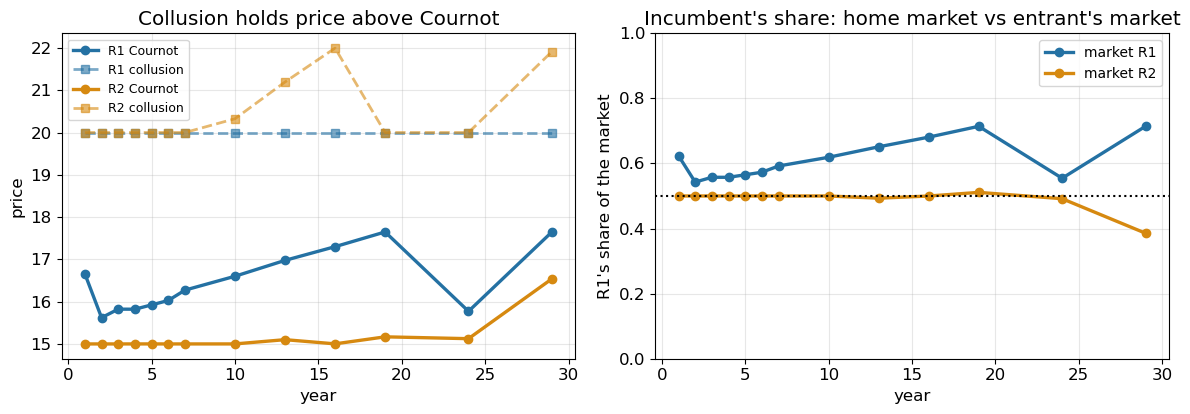

mean share held by R1:
market
R1    0.611
R2    0.491


In [37]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
for mk, col in zip(REGIONS, ['#2471a3', '#d68910']):
    d = mo[mo.market == mk]
    ax[0].plot(d.year, d.price, 'o-', lw=2.4, color=col, label=f'{mk} Cournot')
    dj = mj[mj.market == mk]
    ax[0].plot(dj.year, dj.price, 's--', lw=2.0, color=col, alpha=0.6, label=f'{mk} collusion')
ax[0].set_xlabel('year'); ax[0].set_ylabel('price'); ax[0].legend(fontsize=9)
ax[0].set_title('Collusion holds price above Cournot')
for mk, col in zip(REGIONS, ['#2471a3', '#d68910']):
    d = mo[mo.market == mk]
    ax[1].plot(d.year, d.share_R1, 'o-', lw=2.4, color=col, label=f'market {mk}')
ax[1].axhline(0.5, ls=':', color='k')
ax[1].set_xlabel('year'); ax[1].set_ylabel("R1's share of the market")
ax[1].set_ylim(0, 1); ax[1].legend(fontsize=10)
ax[1].set_title("Incumbent's share: home market vs entrant's market")
plt.tight_layout(); plt.show()

print("mean share held by R1:")
print(mo.groupby('market').share_R1.mean().round(3).to_string())

The share panel shows the asymmetry doing its work. R1 holds about 61% of its **home** market, where
it has both the transport advantage and its accumulated experience, but only about 49% of R2's
market, where the 2.4 cross-region transport premium offsets its lower operating cost. Geography and
experience push in different directions, and the equilibrium splits the difference market by market.

## 11. Does learning drive output? The flooding channel

This is the question Part 3b could not answer. There, cumulative production was pinned by demand, so
production learning was a windfall that changed cost but not a single decision. Here quantity is a
genuine decision, so the channel finally has a lever.

The comparison is `learning='capacity'` (capex learning only) against `learning='both'` (capex plus
the tiered operating cost). Everything else is held fixed.

> **Predict before you run.** Adding a channel that rewards cumulative production — does total
> output go up or down? And if firms want to accumulate production, is *disposal* a cheaper way to do
> it than selling?

In [38]:
rows = []
for lm in ['capacity', 'both']:
    r2 = iterate(learning=lm, tiers=(TIER_Q, TIER_M), nbp_rev=NBP_REV, first='R1',
                 max_iter=MAX_ITER, tol=TOL, mipgap=MIPGAP_GAME)
    last = {g['firm']: g for g in r2['log'][-len(REGIONS):]}
    m2 = pd.DataFrame(market_table(r2['sales']))
    rows.append(dict(learning=lm, status=r2['status'],
                     total_quantity=round(m2.quantity.sum(), 1),
                     avg_price=round(m2.price.mean(), 2),
                     **{f'sales_{r}': round(last[r]['sales'], 1) for r in REGIONS},
                     **{f'profit_{r}': round(last[r]['profit'], 1) for r in REGIONS},
                     disposal=round(sum(last[r]['disposal'] for r in REGIONS), 2)))

learning_table = pd.DataFrame(rows)
assert (learning_table.status == 'CONVERGED').all(), "a learning setting failed to converge"
q_up = 100 * (learning_table.total_quantity[1] / learning_table.total_quantity[0] - 1)
print(f"production learning raises total quantity by {q_up:.1f}% and cuts average price by "
      f"{learning_table.avg_price[0] - learning_table.avg_price[1]:.2f}")
learning_table

production learning raises total quantity by 15.2% and cuts average price by 1.84


,learning,status,total_quantity,avg_price,sales_R1,sales_R2,profit_R1,profit_R2,disposal
0,capacity,CONVERGED,1976.4,17.65,1060.7,915.8,7958.5,5794.5,0.0
1,both,CONVERGED,2276.5,15.81,1247.7,1028.8,11070.7,6720.8,0.0


**Adding the production-learning channel raises total output by 15.2%** (1,976.4 → 2,276.5) and
pushes average price down from 17.65 to 15.81. That is the flooding mechanism, and it is the first
time in this whole series that a learning channel has changed *quantities* rather than only costs.

The logic: a unit sold today is worth more than its immediate margin, because it advances cumulative
production toward a cheaper operating-cost tier. Firms therefore rationally sell **past** the static
profit-maximising quantity — which depresses price for both of them. Learning makes the market more
competitive.

Note also that R1 gains more output than R2 (1,060.7 → 1,247.7, up 17.6%, against 915.8 → 1,028.8,
up 12.3%). The incumbent starts closer to the next tier, so its marginal unit buys more learning.
**Learning-by-doing amplifies incumbency** rather than helping the entrant catch up — a result that
matters for industrial policy and that only appears once quantity is endogenous.

**Disposal stays at exactly zero** in both rows. Firms flood by *selling* at a depressed price, not
by dumping: disposal destroys the revenue while still paying the production cost, so it is dominated.
This confirms the Part 3b calibration — `PEN_DISPOSE = 12` is comfortably above any threshold where
dumping would appear, and the mechanism remains correctly wired and idle.

## 12. The agreement assertion

Everything above was built by hand. `src/lithium/` holds the same model as functions, because
`scripts/run_all.py` and CI need to call it without a notebook kernel. **That means this model exists
twice, deliberately** — and deliberate duplication with nothing comparing the copies is how a bug
gets fixed in three places out of four.

So this cell imports the package, hands it the *same instance dictionaries* and the *same knobs* this
notebook used, runs the same case, and asserts the two objectives agree to $10^{-9}$.

Read the argument list: every knob written out above crosses the boundary here explicitly. That is
why knobs do not need to live in a shared file the way the instance tables do — the assertion already
proves both sides used the same value. And because the package takes the instance as an argument and
never re-reads the CSV, the override you may have uncommented in section 2.2 flows into *both* sides
and this check stays green.

In [39]:
from lithium import Instance, best_response_cournot, build_structure

nb_instance = Instance(
    regions=tuple(REGIONS), stages=tuple(STAGES),
    fixed=FIXED, unit=UNIT, opex=OPEX,
    legacy_cap=LEGACY_CAP, legacy_ret=LEGACY_RET,
    eta_ceil=ETA_CEIL, eta_base=ETA_BASE, alpha=ALPHA, beta=BETA, delta_bar=DELTA_BAR,
    demand_base=DEMAND_BASE, demand_growth=DEMAND_GROWTH, experience0=EXPERIENCE0,
)
nb_struct = build_structure(nb_instance, blocks=BLOCKS, dr=DR, life=LIFE, lead=LEAD,
                            cap_min=CAP_MIN, cap_max=CAP_MAX,
                            legacy_byr=LEGACY_BYR, eta_floor=ETA_FLOOR)

packaged = best_response_cournot(
    FIRM, rival_sales, nb_struct,
    a_int=A_INT, b_slp=B_SLP, nbp_rev=NBP_REV,
    learning='both', mipgap=1e-3,
    transport=TRANSPORT, pen_dispose=PEN_DISPOSE, price_fixed=PRICE_FIXED,
    capex_curve=(QBP, CBP), learn_stages=LEARN_STAGES,
    tiers=(TIER_Q, TIER_M), n_tiers=N_TIERS, lag_years=LAG_YEARS,
)

rel = abs(packaged.ObjVal - hand_built) / abs(hand_built)
print(f"notebook (section 7, by hand): {hand_built:,.9f}")
print(f"package  (lithium.games)     : {packaged.ObjVal:,.9f}")
assert rel < 1e-9, f"notebook and package disagree by {rel:.2e}"
print(f"\nnotebook and package agree to {rel:.1e}")

notebook (section 7, by hand): 22,869.984021205
package  (lithium.games)     : 22,869.984021205

notebook and package agree to 0.0e+00


### 12.1 What this cell would catch

The check is only evidence if it can fail, so it was made to fail on purpose before this notebook
shipped. Flipping the minimum-scale constraint in `src/lithium/regions.py` from
`c >= CAP_MIN * b` to `c >= CAP_MIN * (1 - b)` — a plausible typo, since both forms *look* like a
big-M pairing — produced this:

```
notebook (section 7, by hand): 22,869.984021205
package  (lithium.games)     : -3,257.565407376
AssertionError: notebook and package disagree by 1.14e+00
```

Everything else about that run was unremarkable. The package still built a model, Gurobi still
returned `status 2` (optimal), and every other cell in the notebook was unaffected because the
notebook builds its own copy. Nothing except this comparison noticed.

It also proves the two derivations of the structure agree, not just the final objective: `ETA`,
`MU`, `OMEGA`, `ACTIVE` and `VIN` are all computed twice, once in section 3 and once in
`lithium.structure`, and a discrepancy in any of them would move the objective.

## 13. Summary

| Question | Answer |
|---|---|
| Does endogenous price change the 4b conclusions? | **Yes** — first-mover advantage falls from ~29% to 4.4% |
| Cournot vs collusion? | Collusion cuts output 31%, raises price 15.81 → 20.21, joint profit +28.5% |
| Does production learning drive output now? | **Yes** — +15.2% quantity, price down 1.84 |
| Who benefits from learning? | **The incumbent** — R1 +17.6% output against R2's +12.3% |
| Does pump-and-dump appear? | No. Flooding happens through **sales**, not disposal |
| Pure-strategy equilibrium? | Yes, from both move orders |

### Formulation lessons

- **Curvature and direction together decide whether you need SOS2.** Concave-and-maximised revenue
  (section 7.5) is safe with free $\lambda$; concave-and-minimised cost (section 5.5) is not. Same
  shape, opposite requirement — and both appear in this one notebook.
- **Piecewise-linearising revenue avoided a MIQP entirely** — and kept the model inside the
  size-limited licence.
- **Test convergence on the actual strategy, with a tolerance.** Plans alone declared premature
  convergence; exact quantity hashing invented a 5-cycle out of MIP-gap noise.
- **Results that depend on a rationing rule deserve suspicion.** 4b's first-mover advantage was
  mostly an artefact of the fixed price.
- **Never default an argument to a global.** `def f(..., n=NBP_REV)` freezes the value when the cell
  runs; a later `NBP_REV = 3` then changes nothing at all, silently.

### Things to try

Each of these is a one-line edit to a knob, followed by *Run all*. The section 12 assertion should
stay green through every one of them — if it goes red, something you changed was not passed to the
package.

- `CHOKE = 24` — a flatter market; competition bites harder and margins compress
- `P_ANCHOR = 10` — barely profitable, and capacity investment should collapse
- `NBP_REV = 3` — a coarse revenue mesh; quantities should get visibly blocky
- `TRANSPORT_CROSS = 1.0` — one integrated market instead of two linked ones
- In section 2.2, `EXPERIENCE0['R1'] = 500.0` — remove incumbency and watch the learning
  amplification in section 11 disappear

### Where this goes next

- **4d — Stackelberg.** Leader commits, follower responds. Because the follower's *operational*
  problem is an LP, its KKT conditions can be written explicitly and the bilevel model collapsed to a
  single-level MPEC with big-M complementarity. This is the payoff for keeping flows continuous all
  the way back in Part 3.
- **4e — Policy instruments.** Tariffs as arc-cost adders, quotas as arc bounds, local content
  minimums. Government constrains, firms respond. `lithium.regions.add_region` already carries all
  three as optional arguments that collapse to nothing when empty — which is why the model you
  checked against in section 12 is literally the same function 4e will use.